# Model Architecture Design

This notebook designs the model architecture for the coding agent.

**Approach:**
- Use pre-trained CodeT5 model (encoder-decoder transformer)
- Fine-tune for .NET Core 8+, Angular, TypeScript, and SQL
- Implement custom training configuration

In [ ]:
import torch
import json
from pathlib import Path
from transformers import (
    T5ForConditionalGeneration,
    RobertaTokenizer,
    T5Config
)
import matplotlib.pyplot as plt

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Set paths
PROCESSED_DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Metadata

In [2]:
# Load preprocessing metadata
with open(PROCESSED_DATA_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)

print("Dataset metadata:")
for key, value in metadata.items():
    print(f"  {key}: {value}")

max_seq_length = metadata['max_seq_length']
print(f"\nMax sequence length: {max_seq_length}")

Dataset metadata:
  total_samples: 13
  train_samples: 9
  val_samples: 2
  test_samples: 2
  max_seq_length: 443
  tokenizer: microsoft/codebert-base
  languages: ['csharp', 'typescript', 'sql']
  frameworks: ['dotnet8', 'angular', 'mssql']
  categories: ['controller', 'service', 'model', 'configuration', 'component', 'form', 'guard', 'ddl', 'query', 'procedure', 'index']

Max sequence length: 443


## 2. Initialize Pre-trained Model

Using CodeT5-base for code generation tasks

In [3]:
# Model selection
model_name = "Salesforce/codet5-base"

print(f"Loading model: {model_name}")

# Load tokenizer
tokenizer = RobertaTokenizer.from_pretrained(model_name)
print(f"Tokenizer loaded. Vocabulary size: {tokenizer.vocab_size}")

# Load model
model = T5ForConditionalGeneration.from_pretrained(model_name)
print(f"Model loaded. Parameters: {model.num_parameters():,}")

# Move to device
model = model.to(device)
print(f"Model moved to {device}")

Loading model: Salesforce/codet5-base
Tokenizer loaded. Vocabulary size: 32100
Model loaded. Parameters: 222,882,048
Model moved to cpu


## 3. Model Architecture Overview

In [4]:
# Display model architecture
print("Model Architecture:")
print(model)

# Count parameters by layer type
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
encoder_params = count_parameters(model.encoder)
decoder_params = count_parameters(model.decoder)

print(f"\nParameter breakdown:")
print(f"  Total: {total_params:,}")
print(f"  Encoder: {encoder_params:,}")
print(f"  Decoder: {decoder_params:,}")
print(f"  Other: {total_params - encoder_params - decoder_params:,}")

Model Architecture:
T5ForConditionalGeneration(
  (shared): Embedding(32100, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32100, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
        

## 4. Test Model with Sample Input

In [5]:
# Test with a sample prompt
test_prompt = """Language: csharp
Framework: dotnet8
Task: Create a simple API controller with GET endpoint
Context: ASP.NET Core 8 minimal API controller
"""

print("Testing model with sample input...")
print(f"\nInput prompt:\n{test_prompt}")

# Tokenize input
inputs = tokenizer(
    test_prompt,
    return_tensors="pt",
    max_length=512,
    truncation=True,
    padding=True
).to(device)

print(f"\nInput shape: {inputs['input_ids'].shape}")
print(f"Input tokens: {inputs['input_ids'].shape[1]}")

# Generate output (before training)
with torch.no_grad():
    outputs = model.generate(
        inputs['input_ids'],
        max_length=256,
        num_beams=4,
        early_stopping=True
    )

# Decode output
generated_code = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"\nGenerated output (before fine-tuning):\n{generated_code}")
print("\nNote: Output may not be relevant yet - model needs fine-tuning!")

Testing model with sample input...

Input prompt:
Language: csharp
Framework: dotnet8
Task: Create a simple API controller with GET endpoint
Context: ASP.NET Core 8 minimal API controller


Input shape: torch.Size([1, 37])
Input tokens: 37

Generated output (before fine-tuning):
 public class{

Note: Output may not be relevant yet - model needs fine-tuning!


## 5. Define Training Configuration

In [6]:
# Training hyperparameters
training_config = {
    # Model
    'model_name': model_name,
    'max_input_length': 512,
    'max_output_length': 512,
    
    # Training
    'num_epochs': 10,
    'batch_size': 4,  # Adjust based on GPU memory
    'learning_rate': 5e-5,
    'weight_decay': 0.01,
    'warmup_steps': 500,
    
    # Generation
    'num_beams': 4,
    'temperature': 0.7,
    'top_p': 0.95,
    
    # Optimization
    'gradient_accumulation_steps': 4,
    'max_grad_norm': 1.0,
    
    # Evaluation
    'eval_steps': 100,
    'save_steps': 500,
    'logging_steps': 50,
    
    # Early stopping
    'early_stopping_patience': 3,
    'early_stopping_threshold': 0.001
}

print("Training Configuration:")
for key, value in training_config.items():
    print(f"  {key}: {value}")

# Save configuration
with open(MODEL_DIR / 'training_config.json', 'w') as f:
    json.dump(training_config, f, indent=2)

print(f"\nConfiguration saved to: {MODEL_DIR / 'training_config.json'}")

Training Configuration:
  model_name: Salesforce/codet5-base
  max_input_length: 512
  max_output_length: 512
  num_epochs: 10
  batch_size: 4
  learning_rate: 5e-05
  weight_decay: 0.01
  warmup_steps: 500
  num_beams: 4
  temperature: 0.7
  top_p: 0.95
  gradient_accumulation_steps: 4
  max_grad_norm: 1.0
  eval_steps: 100
  save_steps: 500
  logging_steps: 50
  early_stopping_patience: 3
  early_stopping_threshold: 0.001

Configuration saved to: ..\models\training_config.json


## 6. Estimate Training Time and Resources

In [7]:
# Calculate training estimates
train_samples = metadata['train_samples']
batch_size = training_config['batch_size']
num_epochs = training_config['num_epochs']
grad_accum_steps = training_config['gradient_accumulation_steps']

steps_per_epoch = train_samples // (batch_size * grad_accum_steps)
total_steps = steps_per_epoch * num_epochs

print("Training Estimates:")
print(f"  Training samples: {train_samples}")
print(f"  Effective batch size: {batch_size * grad_accum_steps}")
print(f"  Steps per epoch: {steps_per_epoch}")
print(f"  Total training steps: {total_steps}")
print(f"  Evaluation frequency: every {training_config['eval_steps']} steps")
print(f"  Checkpoint frequency: every {training_config['save_steps']} steps")

# Estimate time (rough estimate: 0.5-2 seconds per step on GPU)
if device.type == 'cuda':
    time_per_step = 1.0  # seconds (rough estimate)
    total_time_hours = (total_steps * time_per_step) / 3600
    print(f"\nEstimated training time (GPU): {total_time_hours:.2f} hours")
else:
    print("\nWarning: Training on CPU will be very slow!")
    print("Recommendation: Use GPU or reduce dataset size for testing")

Training Estimates:
  Training samples: 9
  Effective batch size: 16
  Steps per epoch: 0
  Total training steps: 0
  Evaluation frequency: every 100 steps
  Checkpoint frequency: every 500 steps

Recommendation: Use GPU or reduce dataset size for testing


## 7. Model Summary Visualization

⚠ Warning: Encoder + Decoder exceeds total params. Setting 'Other' to 0.


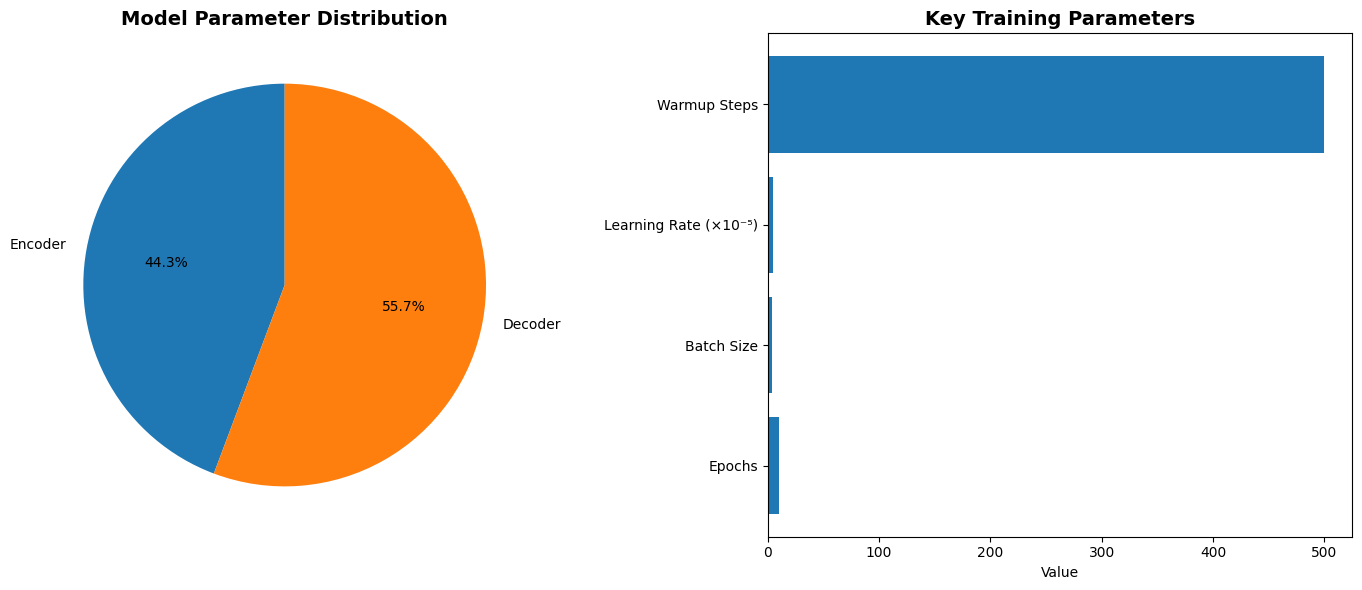


MODEL ARCHITECTURE READY!

Model: Salesforce/codet5-base
Total parameters: 222,882,048
Device: cpu

Next step: Run notebook 04_training.ipynb to train the model


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- SAFE PARAMETER CALCULATION ----
other_params = total_params - (encoder_params + decoder_params)

if other_params < 0:
    print("⚠ Warning: Encoder + Decoder exceeds total params. Setting 'Other' to 0.")
    other_params = 0

param_dist = {
    'Encoder': encoder_params,
    'Decoder': decoder_params,
}

if other_params > 0:
    param_dist['Other'] = other_params

# ---- PIE CHART ----
axes[0].pie(
    list(param_dist.values()),
    labels=list(param_dist.keys()),
    autopct='%1.1f%%',
    startangle=90
)

axes[0].set_title('Model Parameter Distribution', fontsize=14, fontweight='bold')

# ---- TRAINING CONFIG BAR CHART ----
config_items = ['Epochs', 'Batch Size', 'Learning Rate (×10⁻⁵)', 'Warmup Steps']
config_values = [
    training_config['num_epochs'],
    training_config['batch_size'],
    training_config['learning_rate'] * 100000,
    training_config['warmup_steps']
]

axes[1].barh(config_items, config_values)
axes[1].set_title('Key Training Parameters', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Value')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("MODEL ARCHITECTURE READY!")
print("="*50)
print(f"\nModel: {model_name}")
print(f"Total parameters: {total_params:,}")
print(f"Device: {device}")
print(f"\nNext step: Run notebook 04_training.ipynb to train the model")